# Installs & imports

In [27]:
%pip install deap
%pip install python-chess
%pip install optuna
# restart kernel after install

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import chess
import random
from deap import base, creator, tools, algorithms
import operator
import functools
import numpy as np
import chess.pgn
import pandas as pd
import os
import shelve
import pickle
import atexit
import time
import matplotlib.pyplot as plt

# Create dataset

elo > 2400 is considered a senior master: https://en.wikipedia.org/wiki/Elo_rating_system

In [ ]:
import re

def filter_games_by_elo(input_path, output_path, min_elo=2400, require_both=False):
    """
    Write games where White or Black (or both if require_both=True) have Elo >= min_elo.
    """
    result_pattern = re.compile(r"\s*(1-0|0-1|1/2-1/2)\s*$")
    elo_pattern = re.compile(r'\[(WhiteElo|BlackElo)\s+"(\d+)"\]')
    current_game = []
    white_elo = None
    black_elo = None

    with open(input_path, "r", encoding="utf-8") as infile, open(output_path, "w", encoding="utf-8") as outfile:
        for line in infile:
            current_game.append(line)
            m = elo_pattern.match(line.strip())
            if m:
                tag, val = m.group(1), int(m.group(2))
                if tag == "WhiteElo":
                    white_elo = val
                else:
                    black_elo = val

            if result_pattern.search(line):
                if require_both:
                    keep = (white_elo is not None and black_elo is not None and
                            white_elo >= min_elo and black_elo >= min_elo)
                else:
                    keep = ((white_elo is not None and white_elo >= min_elo) or
                            (black_elo is not None and black_elo >= min_elo))

                if keep:
                    outfile.write("".join(current_game))
                    outfile.write("\n\n")  # Separate games

                current_game = []
                white_elo = None
                black_elo = None

# Usage example
filter_games_by_elo(
    input_path="lichess_dataset/lichess_db_standard_rated_2025-10.pgn/lichess_db_standard_rated_2025-10.pgn",
    output_path="lichess_dataset/high_elo_games.pgn",
    min_elo=2400,
    require_both=False
)

# Create methods

In [2]:
def create_individual():
    individual = creator.Individual([random.random(),random.random(),random.random(),random.random(),random.random()])
    return individual

In [37]:
def create_population(n):
    pop = []
    # best of a previous run
    pop.append(creator.Individual([0.784230656365722, 0.029088370337828393, 0.3218419652066543, 0.041982679330333963, 0.05719557077638733]))
    # starting function
    pop.append(creator.Individual([1.0, 0.1, 0.2, 0.5, 0.3]))
    # best of a previous run
    pop.append(creator.Individual([0.5888401286952537, -0.005715796324852262, 0.31468903762880196, 0.015409176298030229, -0.14100841437780845]))
    # best of a previous run
    pop.append(creator.Individual([0.748136509986382, -0.022198206341317656, 0.4316496798496232, 0.00470096163849925, -1.3673789132942211]))
    pop.append(creator.Individual([1.0343127398974012, -0.018995447401136647, 0.08382726478255974, 0.10591396845825597, 0.6374475126755172]))
    
    for _ in range(len(pop), n):
        pop.append(create_individual())
    return pop
    

In [7]:
PIECE_VALUES = {
    chess.PAWN:   1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK:   5,
    chess.QUEEN:  9,
    chess.KING:   0  # king handled separately
}

def material_score(board, color):
    score = 0
    for piece_type, value in PIECE_VALUES.items():
        score += len(board.pieces(piece_type, color)) * value
        score -= len(board.pieces(piece_type, not color)) * value
    return score

# https://chessfox.com/how-to-measure-center-control-in-chess/
CENTER_SQUARES = [
    chess.E4, chess.D4, chess.E5, chess.D5
]

def center_control(board, color):
    control = 0
    for sq in CENTER_SQUARES:
        if board.is_attacked_by(color, sq):
            control += 1
        if board.is_attacked_by(not color, sq):
            control -= 1
    return control

In [8]:
def calculate_score(board, color):
    material = material_score(board, color)

    # Mobility
    mobility = board.legal_moves.count()

    # Center control
    center = center_control(board, color)

    # Check / checkmate bonus
    check_bonus = 0
    if board.is_checkmate():
        check_bonus = 100
    elif board.is_check():
        check_bonus = 5

    # King safety (simple)
    king_square = board.king(color)
    king_exposure = 0
    if king_square is not None:
        attackers = board.attackers(not color, king_square)
        king_exposure = len(attackers)

    return material, mobility, center, check_bonus, king_exposure 

In [10]:
# with weighted top-k prediction
def evaluation_fitness(individual, pgn_path="lichess_dataset/high_elo_games.pgn",
                       n_games=100, min_elo=2400, move_range=(10,80),
                       samples_per_game=5, top_k=5,
                       w_top1=1.0, w_top3=0.6, w_top5=0.3):
    """
    Fitness = average weighted score:
      - w_top1 if actual move ranks #1
      - w_top3 if in top 3 (but not #1)
      - w_top5 if in top 5 (but not top 3)
      - 0 otherwise
    """
    weights = list(individual)

    total_score = 0.0
    total = 0
    processed = 0

    with open(pgn_path, "r", encoding="utf-8") as f:
        while processed < n_games:
            game = chess.pgn.read_game(f)
            if game is None:
                break

            try:
                w_elo = int(game.headers.get("WhiteElo", "0"))
            except Exception:
                w_elo = 0
            try:
                b_elo = int(game.headers.get("BlackElo", "0"))
            except Exception:
                b_elo = 0

            candidates = []
            if w_elo >= min_elo:
                candidates.append(("white", w_elo))
            if b_elo >= min_elo:
                candidates.append(("black", b_elo))
            if not candidates:
                continue
            target_color = chess.WHITE if max(candidates, key=lambda x: x[1])[0] == "white" else chess.BLACK

            board = game.board()
            moves = list(game.mainline_moves())
            positions = []

            for idx, mv in enumerate(moves):
                board.push(mv)
                fm = board.fullmove_number
                if move_range[0] <= fm <= move_range[1] and board.turn == target_color:
                    if idx + 1 < len(moves):
                        next_move = moves[idx + 1]
                        positions.append((board.copy(), next_move))

            if not positions:
                processed += 1
                continue

            idxs = np.linspace(0, len(positions) - 1, min(samples_per_game, len(positions))).astype(int)
            for i in idxs:
                pos_board, next_move = positions[i]
                mover = pos_board.turn

                scored = []
                for mv in pos_board.legal_moves:
                    pos_board.push(mv)
                    feats = calculate_score(pos_board, mover)
                    val = sum(w * float(fe) for w, fe in zip(weights, feats))
                    pos_board.pop()
                    scored.append((val, mv.uci()))

                if not scored:
                    continue

                scored.sort(key=lambda x: x[0], reverse=True)
                # find rank of the actual move
                rank = next((r for r, (_, uci) in enumerate(scored) if uci == next_move.uci()), None)
                if rank is None:
                    continue

                if rank == 0:
                    total_score += w_top1
                elif rank < 3:
                    total_score += w_top3
                elif rank < top_k:
                    total_score += w_top5
                # else 0

                total += 1

            processed += 1

    if total == 0:
        return 0.0
    return float(total_score / total)

In [ ]:
# fitness of the function we started with
evaluation_fitness(creator.Individual([1.0, 0.1, 0.2, 0.5, 0.3]))

0.3266666666666662

In [36]:
# fitness of our best individual
evaluation_fitness(creator.Individual([1.0343127398974012,
 -0.018995447401136647,
 0.08382726478255974,
 0.10591396845825597,
 0.6374475126755172]))

0.35050505050505015

In [12]:
def selElitistAndRoulette(individuals, pop_size, k_elitist):
    return tools.selBest(individuals, k_elitist) + tools.selRoulette(individuals, pop_size - k_elitist)

In [13]:
def run_ga_deap(n_pop, n_gen, cxpb, mutpb):
    """
    Run genetic algorithm using DEAP to find best evaluation function on a chess board
    """
    # Create population with individuals that are legal moves on this board
    pop = create_population(n_pop)
    
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Evaluate initial population
    fitnesses = [evaluation_fitness(ind) for ind in pop]
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = (fit,)

    logbook = tools.Logbook()
    logbook.record(gen=0, nevals=len(pop), **stats.compile(pop))
    
    best_fitness_so_far = max([ind.fitness.values[0] for ind in pop])
    print(f"Gen 0: Best fitness = {best_fitness_so_far:.4f}")

    k_elitist = int(0.1 * n_pop)

    for gen in range(1, n_gen + 1):
        elites = tools.selBest(pop, k_elitist)
        elite_fitness = [ind.fitness.values[0] for ind in elites]
        print(f"\nGen {gen}: Elite fitness before = {max(elite_fitness):.4f}")
        
        offspring = toolbox.select(pop, n_pop - k_elitist)
        offspring = [toolbox.clone(ind) for ind in offspring]

        for i in range(1, len(offspring), 2):
            if random.random() < cxpb:
                toolbox.mate(offspring[i - 1], offspring[i])
                del offspring[i - 1].fitness.values
                del offspring[i].fitness.values

        for i in range(len(offspring)):
            if random.random() < mutpb:
                toolbox.mutate(offspring[i])
                del offspring[i].fitness.values

        # Evaluate offspring on the SAME board
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = [evaluation_fitness(ind) for ind in invalid_ind]
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = (fit,)

        pop = elites + offspring
        
        pop_best = max([ind.fitness.values[0] for ind in pop])
        print(f"Gen {gen}: Best in combined pop = {pop_best:.4f}: {ind}")
        
        if max(elite_fitness) > pop_best:
            print(f"⚠️  WARNING: Elite fitness {max(elite_fitness):.4f} > pop best {pop_best:.4f}")

        hof.update(pop)
        record = stats.compile(pop)
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        
        current_max = record['max']
        print(f"Gen {gen}: Max fitness = {current_max:.4f}, Avg = {record['avg']:.4f}")
        
        if current_max < best_fitness_so_far:
            print(f"❌ DECREASE: {best_fitness_so_far:.4f} → {current_max:.4f}")
        else:
            best_fitness_so_far = current_max

    return pop, hof, logbook

# Run algorithm

In [21]:
n_population = 200
crossover_per = 0.8
mutation_per = 0.5
n_generations = 10

In [38]:
# Clear any existing fitness/individual classes
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Initialize DEAP toolbox
toolbox = base.Toolbox()

# Fixed board for evaluation
eval_board = chess.Board()

# Register operators
toolbox.register("individual", functools.partial(create_individual))
toolbox.register("population", functools.partial(create_population))
toolbox.register("evaluate", functools.partial(evaluation_fitness))

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.1, indpb=0.2)
toolbox.register("select", selElitistAndRoulette, k_elitist=int(0.1*n_population))

# Execute DEAP GA
print("Running DEAP Genetic Algorithm for Chess Evaluation function...")
print(f"Population: {n_population}, Generations: {n_generations}")
print(f"Crossover: {crossover_per}, Mutation: {mutation_per}\n")

pop_deap, hof_deap, logbook_deap = run_ga_deap(n_population, n_generations, 
                                                    crossover_per, mutation_per)

# Extract best solution
print("\n" + "="*50)
print("DEAP GA Results")
print("="*50)
best_individual_deap = hof_deap[0]
best_fitness_deap = evaluation_fitness(best_individual_deap)
print(f"Best evaluation found: {best_fitness_deap:.3f}")
print(f"Best individual: {tuple(best_individual_deap)}")

Running DEAP Genetic Algorithm for Chess Evaluation function...
Population: 200, Generations: 10
Crossover: 0.8, Mutation: 0.5

Gen 0: Best fitness = 0.3505

Gen 1: Elite fitness before = 0.3505
Gen 1: Best in combined pop = 0.3505: [0.8021289915802564, 0.1686077263597238, 0.6742983280207846, 0.533089492431021, 0.5845816947098299]
Gen 1: Max fitness = 0.3505, Avg = 0.2378

Gen 2: Elite fitness before = 0.3505
Gen 2: Best in combined pop = 0.3505: [0.4514250318224558, -0.03641870279599191, 0.7364306276932453, 0.6003807290598877, 0.6690353872842902]
Gen 2: Max fitness = 0.3505, Avg = 0.2637

Gen 3: Elite fitness before = 0.3505
Gen 3: Best in combined pop = 0.3505: [0.5582355253585425, 0.4148165164532328, 0.36508307586332056, 0.5772818758645033, 0.8297320689905208]
Gen 3: Max fitness = 0.3505, Avg = 0.2923

Gen 4: Elite fitness before = 0.3505
Gen 4: Best in combined pop = 0.3505: [0.7633174763824566, 0.27836293529293993, -0.03992630465282191, -0.05920093912051279, 0.07298667432877667]
G

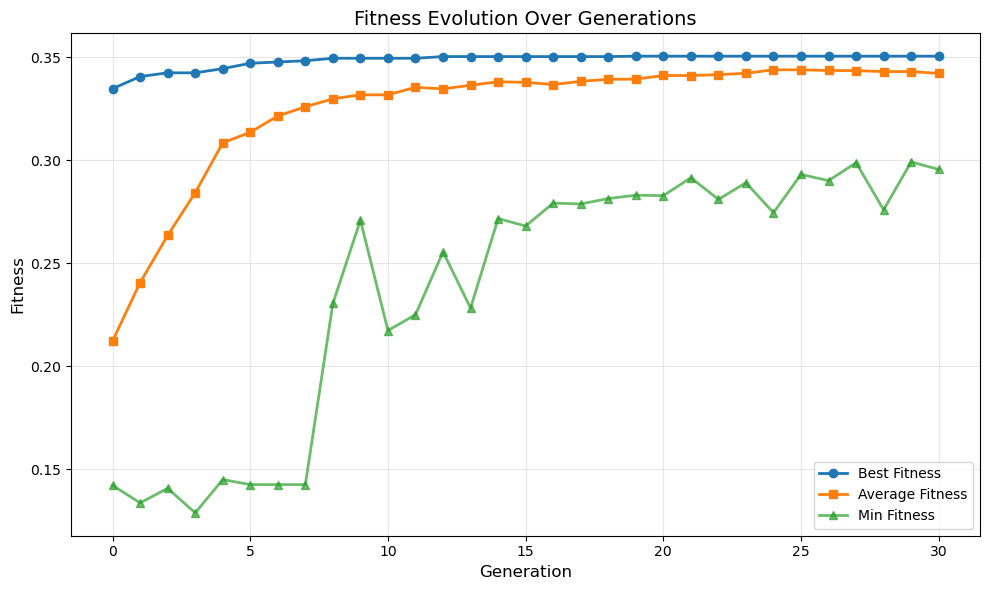

In [18]:
# Extract data from logbook
generations = logbook_deap.select("gen")
max_fitness = logbook_deap.select("max")
avg_fitness = logbook_deap.select("avg")
min_fitness = logbook_deap.select("min")

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(generations, max_fitness, label='Best Fitness', marker='o', linewidth=2)
plt.plot(generations, avg_fitness, label='Average Fitness', marker='s', linewidth=2)
plt.plot(generations, min_fitness, label='Min Fitness', marker='^', linewidth=2, alpha=0.7)

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Fitness Evolution Over Generations', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

^^ crossover 0.8, mutation 0.2

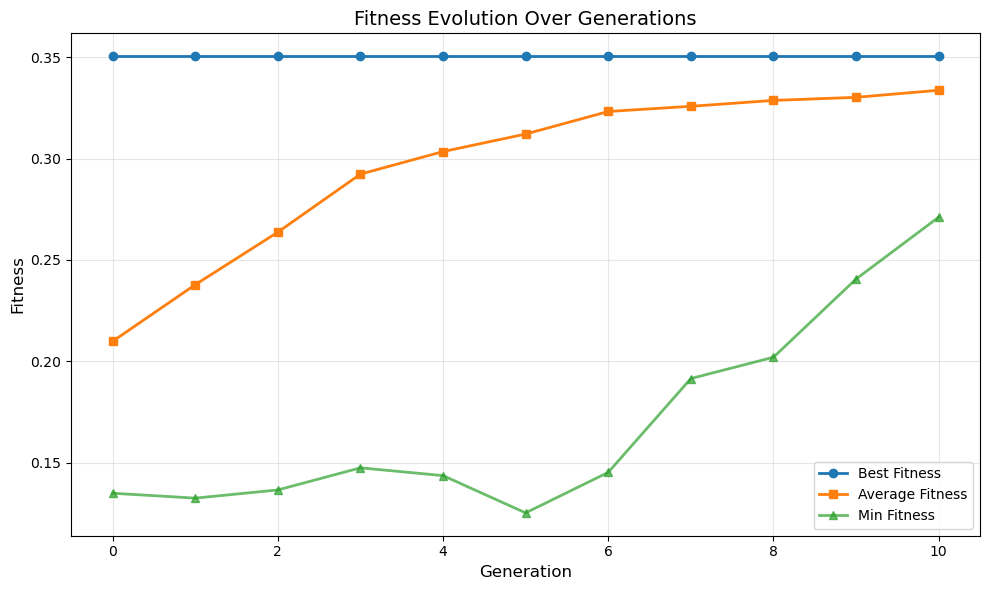

In [39]:
# Extract data from logbook
generations = logbook_deap.select("gen")
max_fitness = logbook_deap.select("max")
avg_fitness = logbook_deap.select("avg")
min_fitness = logbook_deap.select("min")

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(generations, max_fitness, label='Best Fitness', marker='o', linewidth=2)
plt.plot(generations, avg_fitness, label='Average Fitness', marker='s', linewidth=2)
plt.plot(generations, min_fitness, label='Min Fitness', marker='^', linewidth=2, alpha=0.7)

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Fitness Evolution Over Generations', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

^^ crossover 0.8, mutation rate 0.5

# Bayesian optimization search
To verify if there are any easy to grab parameter optimizations, we do a search using the optuna framework. 

In [40]:
def evaluate(a):
    return evaluation_fitness(creator.Individual(a))

In [41]:
import optuna

def objective(trial):
    x = [trial.suggest_float(f"x{i}", -1.0, 1.0) for i in range(5)]
    return evaluate(x)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)

print(study.best_params, study.best_value)


[I 2025-12-29 17:26:27,790] A new study created in memory with name: no-name-633066d7-b7a1-42ee-9199-0638275d7ccd
[I 2025-12-29 17:26:29,749] Trial 0 finished with value: 0.172121212121212 and parameters: {'x0': 0.20751126828158806, 'x1': 0.82516527185194, 'x2': 0.8227405595539217, 'x3': 0.30670337281002236, 'x4': 0.27373868152598213}. Best is trial 0 with value: 0.172121212121212.
[I 2025-12-29 17:26:31,691] Trial 1 finished with value: 0.14101010101010095 and parameters: {'x0': -0.5878261956864801, 'x1': 0.9692847268982565, 'x2': -0.6984009329022303, 'x3': 0.6581550519607606, 'x4': 0.009574312672278484}. Best is trial 0 with value: 0.172121212121212.
[I 2025-12-29 17:26:33,603] Trial 2 finished with value: 0.19939393939393907 and parameters: {'x0': -0.6994230432415356, 'x1': -0.37178039417684117, 'x2': -0.9401659699832947, 'x3': 0.5555446292914659, 'x4': 0.0808274310324606}. Best is trial 2 with value: 0.19939393939393907.
[I 2025-12-29 17:26:35,515] Trial 3 finished with value: 0.12

{'x0': 0.572723299680121, 'x1': -0.015385044530087683, 'x2': 0.0947485418513169, 'x3': 0.04149843478979087, 'x4': 0.07763399492038808} 0.3476767676767673


# calculate with more features

## Create fitness dataset with features

In [55]:
def adv_rank_from(sq, perspective):
    r = chess.square_rank(sq)        # 0..7 from White's side
    return r if perspective == chess.WHITE else 7 - r

In [211]:
# Features inspired on https://u.cs.biu.ac.il/~koppel/papers/ALL_TEVC-00235-2012.pdf
FEATURE_CACHE = {}
CACHE_PATH = os.path.join('lichess_dataset', 'feature_cache.db')

def load_feature_cache():
    try:
        with shelve.open(CACHE_PATH) as db:
            for k in db:
                FEATURE_CACHE[k] = db[k]
    except Exception:
        pass

def save_feature_cache():
    try:
        with shelve.open(CACHE_PATH) as db:
            for k, v in FEATURE_CACHE.items():
                db[k] = v
    except Exception:
        pass

load_feature_cache()

def calculate_features(board, color):
    """Calculate chess evaluation features for a given position and color,
    including opponent features and deltas (own - opponent).
    Cached by FEN+color to avoid recomputation."""
    fen = board.fen()
    key = fen + ('_w' if color else '_b')
    if key in FEATURE_CACHE:
        return FEATURE_CACHE[key]

    features = {}
    opp = not color

    # Material counts per color (number of pieces per color)
    for piece, name in ((chess.PAWN, 'PAWN'),
                        (chess.KNIGHT, 'KNIGHT'),
                        (chess.BISHOP, 'BISHOP'),
                        (chess.ROOK, 'ROOK'),
                        (chess.QUEEN, 'QUEEN')):
        white_cnt = len(board.pieces(piece, chess.WHITE))
        black_cnt = len(board.pieces(piece, chess.BLACK))
        features[f'{name}_WHITE'] = white_cnt
        features[f'{name}_BLACK'] = black_cnt

    # Pawn advancement (own, opp, diff)
    pawn_advance_a = sum(1 for sq in board.pieces(chess.PAWN, color) if (sq // 8) >= 3)
    pawn_advance_b = sum(1 for sq in board.pieces(chess.PAWN, color) if (sq // 8) >= 5)
    features['PAWN_ADVANCE_A'] = pawn_advance_a
    features['PAWN_ADVANCE_B'] = pawn_advance_b

    # Bishop features
    bishop_moves = sum(len(list(board.attacks(sq))) for sq in board.pieces(chess.BISHOP, color))
    features['BISHOP_MOBILITY'] = bishop_moves
    features['BISHOP_PAIR'] = 1 if len(board.pieces(chess.BISHOP, color)) >= 2 else 0

    # Queen features
    queen_moves = sum(len(list(board.attacks(sq))) for sq in board.pieces(chess.QUEEN, color))
    features['QUEEN_MOBILITY'] = queen_moves

    # Mobility (legal moves) for both sides and diff
    b_own = board.copy(); b_own.turn = color
    b_opp = board.copy(); b_opp.turn = opp
    features['MOBILITY'] = b_own.legal_moves.count()

    # King safety: attackers on king for both sides
    king_sq = board.king(color)
    features['KING_ATTACKERS'] = len(board.attackers(opp, king_sq)) if king_sq is not None else 0

    FEATURE_CACHE[key] = features
    return features

def extract_positions_from_games(pgn_path, n_positions=10000, min_white_elo=2400):
    """Extract positions only when it's White's turn and White's Elo > min_white_elo.
    Adds FEN and next-move columns. Does NOT use positions where Black is to move."""
    rows = []
    games_processed = 0

    with open(pgn_path, 'r', encoding='utf-8') as f:
        while len(rows) < n_positions:
            game = chess.pgn.read_game(f)
            if game is None:
                break

            # Require WhiteElo and enforce threshold
            try:
                white_elo = int(game.headers.get('WhiteElo', '0'))
            except:
                games_processed += 1
                continue

            if white_elo <= min_white_elo:
                games_processed += 1
                continue

            # iterate moves with index so we can get the "next move" for a recorded position
            moves = list(game.mainline_moves())
            board = game.board()
            for idx, mv in enumerate(moves):
                board.push(mv)
                # Only record positions where it's White's turn and in midgame range
                if board.turn == chess.WHITE and 10 <= board.fullmove_number <= 60:
                    features = calculate_features(board, chess.WHITE)
                    row = features.copy()
                    row['FEN'] = board.fen()

                    next_move = moves[idx + 1] if idx + 1 < len(moves) else None
                    if next_move is not None:
                        try:
                            next_move_san = board.san(next_move)
                        except Exception:
                            next_move_san = None
                        next_move_uci = next_move.uci()
                    else:
                        next_move_san = None
                        next_move_uci = None

                    row['NEXT_MOVE_SAN'] = next_move_san
                    row['NEXT_MOVE_UCI'] = next_move_uci

                    rows.append(row)

                    if len(rows) >= n_positions:
                        break

            games_processed += 1
            if games_processed % 100 == 0:
                print(f"Processed {games_processed} games, extracted {len(rows)} positions")

    df = pd.DataFrame(rows)
    return df.head(n_positions)

# Extract positions
df_positions = extract_positions_from_games(
    'lichess_dataset/high_elo_games.pgn',
    n_positions=10000
)

df_positions.to_parquet(os.path.join('lichess_dataset', "high_elo_positions.parquet"), index=False)


print(f"\nDataFrame shape: {df_positions.shape}")
print(f"\nColumns: {df_positions.columns.tolist()}")
print(f"\nFirst few rows:\n{df_positions.head()}")

Processed 100 games, extracted 2752 positions
Processed 200 games, extracted 5030 positions
Processed 400 games, extracted 10000 positions

DataFrame shape: (10000, 20)

Columns: ['PAWN_WHITE', 'PAWN_BLACK', 'KNIGHT_WHITE', 'KNIGHT_BLACK', 'BISHOP_WHITE', 'BISHOP_BLACK', 'ROOK_WHITE', 'ROOK_BLACK', 'QUEEN_WHITE', 'QUEEN_BLACK', 'PAWN_ADVANCE_A', 'PAWN_ADVANCE_B', 'BISHOP_MOBILITY', 'BISHOP_PAIR', 'QUEEN_MOBILITY', 'MOBILITY', 'KING_ATTACKERS', 'FEN', 'NEXT_MOVE_SAN', 'NEXT_MOVE_UCI']

First few rows:
   PAWN_WHITE  PAWN_BLACK  KNIGHT_WHITE  KNIGHT_BLACK  BISHOP_WHITE  \
0           7           7             2             2             2   
1           7           7             2             2             2   
2           7           7             2             2             2   
3           7           7             2             2             2   
4           7           7             2             2             2   

   BISHOP_BLACK  ROOK_WHITE  ROOK_BLACK  QUEEN_WHITE  QUEEN_BLACK  

## Load dataset

In [212]:
path = os.path.join('lichess_dataset', "high_elo_positions.parquet")
df = pd.read_parquet(path)
df.head()

,PAWN_WHITE,PAWN_BLACK,KNIGHT_WHITE,KNIGHT_BLACK,BISHOP_WHITE,BISHOP_BLACK,ROOK_WHITE,ROOK_BLACK,QUEEN_WHITE,QUEEN_BLACK,PAWN_ADVANCE_A,PAWN_ADVANCE_B,BISHOP_MOBILITY,BISHOP_PAIR,QUEEN_MOBILITY,MOBILITY,KING_ATTACKERS,FEN,NEXT_MOVE_SAN,NEXT_MOVE_UCI
0,7,7,2,2,2,2,2,2,1,1,2,0,10,1,12,40,0,r2qk1nr/1p3pbp/p1npb1p1/4p3/2P1P3/2N5/PPN2PPP/...,Bd3,f1d3
1,7,7,2,2,2,2,2,2,1,1,2,0,11,1,9,39,0,r2qk2r/1p3pbp/p1npbnp1/4p3/2P1P3/2NB4/PPN2PPP/...,O-O,e1g1
2,7,7,2,2,2,2,2,2,1,1,2,0,11,1,10,36,0,r2q1rk1/1p3pbp/p1npbnp1/4p3/2P1P3/2NB4/PPN2PPP...,Nd5,c3d5
3,7,7,2,2,2,2,2,2,1,1,2,0,11,1,10,39,0,r2q1rk1/1p1n1pbp/p1npb1p1/3Np3/2P1P3/3B4/PPN2P...,Be3,c1e3
4,7,7,2,2,2,2,2,2,1,1,2,0,13,1,12,41,0,r2q1rk1/1p3pbp/p1npb1p1/2nNp3/2P1P3/3BB3/PPN2P...,b4,b2b4


## Create methods

In [307]:
def get_feature_columns():
    # adapt if you added/rename non-feature columns
    non_feature_cols = {'FEN', 'NEXT_MOVE_SAN', 'NEXT_MOVE_UCI'}
    return [c for c in df.columns if c not in non_feature_cols]


In [308]:
def create_individual_multi():
    n = len(get_feature_columns())
    return creator.Individual([random.uniform(-1, 1) for _ in range(n)])


In [325]:
def create_population_multi(n):
    pop = []
    # # add seeded individual: first 10 values as specified (calculated according to material piece values), rest 0.1
    # seed_vals = [1/9, -1/9, 1/3, -1/3, 1/3, -1/3, 5/9, -5/9, 1.0, -1.0]
    # m = len(get_feature_columns())
    # if m >= len(seed_vals):
    #     seeded = seed_vals + [0.1] * (m - len(seed_vals))
    # else:
    #     seeded = seed_vals[:m]
    # pop.append(creator.Individual([float(x) for x in seeded]))
    
    # best result from a previous run
    pop.append(creator.Individual([-1.0873009176628439, -0.38078305844044985, 0.6307936124614943, -0.5204613869328434, -0.35303823512017457, 1.7542341442768565, 
                                   -1.6472401075765926, -0.912106547005759, -0.0731282669109081, -1.381251322102865, 0.059323378633409474, 0.3481532658512918, 
                                   0.04045888817342826, 0.18966256744319002, 0.005279542940611828, -0.0055093351045220115, -1.5156966565277261]))
    pop.append(creator.Individual([-1.0888731754713823, -0.1361868105994744, -1.9048243617229752, -0.5187816161473813, -0.6620197180393622, -0.7698744869968552, 
                                   -1.6478663697957439, -0.9334863746500707, -0.06291650162279078, -1.3109377798035717, 0.03595210758810784, 0.3431026276352392, 
                                   0.04045888817342826, 0.1896421214759826, -0.0696671492338362, -0.005534680501319831, -1.5147631475042458]))
    pop.append(creator.Individual([-1.1539608071684364, -0.40659559026676406, -1.261849583672119, -0.6839893643881854, -0.9751743665225067, -0.8779975960358554, 
                                   -1.2548222807359641, -1.5906266354095002, 0.06258948551649757, -1.6492130289446467, 0.05701654432226999, 0.2798002596558455, 
                                   0.014825359188262457, 0.2016567010398534, -0.0281001748521512, 0.021806139409058782, -0.8797964276006605]))
    pop.append(creator.Individual([-0.7928968083537473, -0.23851239825596418, -1.8351996069731817, -0.6687648185565835, -0.9576808325439847, -1.1364936311301346, 
                                   -1.2803935298083549, -1.4553107979535163, 0.06258948551649757, -1.093817221118794, 0.27974818628998643, 0.27964589138388085, 
                                   0.23246032382632437, 0.2036963756706297, 0.024634943861583172, 0.024075171703528797, -0.6837641381167757]))
    pop.append(creator.Individual([-1.1539608071684364, -0.40659559026676406, -1.261849583672119, -0.6839893643881854, -0.9751743665225067, -0.8779975960358554, 
                                   -1.2548222807359641, -1.5906266354095002, 0.06258948551649757, -1.6492130289446467, 0.05701654432226999, 0.2798002596558455, 
                                   0.014825359188262457, 0.2016567010398534, -0.0281001748521512, 0.021806139409058782, -0.8797964276006605]))
    for _ in range(len(pop), n):
        pop.append(create_individual_multi())
    return pop

In [310]:
def calculate_score_multi(ind, df_row):
    # ind: list of weights, df_row: pandas Series
    features = get_feature_columns()
    vals = [float(df_row[f]) for f in features]
    return sum(w * v for w, v in zip(ind, vals)) / max(1, len(vals))

In [311]:
def evaluate_fitness_multi(individual, sample_n=None):
    """
    Fitness = fraction of positions where the evaluated-best move (by this individual's weights)
    equals the dataframe NEXT_MOVE_UCI. Optionally sample `sample_n` rows for speed.
    """
    features = get_feature_columns()
    weights = np.array(individual, dtype=float)

    rows = df if sample_n is None else df.sample(n=sample_n, random_state=1)
    total = 0
    correct = 0

    for _, row in rows.iterrows():
        fen = row.get("FEN")
        next_uci = row.get("NEXT_MOVE_UCI")
        if pd.isna(fen) or pd.isna(next_uci):
            continue

        try:
            board = chess.Board(fen)
        except Exception:
            continue

        mover_color = board.turn  # the side that played NEXT_MOVE_UCI in this row

        best_score = -np.inf
        best_move_uci = None

        # evaluate each legal move by scoring resulting position from mover's perspective
        for mv in board.legal_moves:
            board.push(mv)
            feat_dict = calculate_features(board, mover_color)
            vals = [float(feat_dict.get(f, 0.0)) for f in features]
            score = float(np.dot(weights, vals))
            board.pop()

            if score > best_score:
                best_score = score
                best_move_uci = mv.uci()

        if best_move_uci is None:
            continue

        total += 1
        if best_move_uci == next_uci:
            correct += 1

    if total == 0:
        return 0.0
    return float(correct / total)


In [312]:
def evaluate_fitness_multi_weighted(individual, sample_n=None):
    """
    Weighted fitness:
    - 1.0 points if actual move is #1
    - 0.6 points if in top 3
    - 0.3 points if in top 5
    - 0.0 otherwise
    """
    features = get_feature_columns()
    weights = np.array(individual, dtype=float)

    rows = df if sample_n is None else df.sample(n=sample_n, random_state=1)
    total_score = 0.0
    total_positions = 0

    for _, row in rows.iterrows():
        fen = row.get("FEN")
        next_uci = row.get("NEXT_MOVE_UCI")
        if pd.isna(fen) or pd.isna(next_uci):
            continue

        try:
            board = chess.Board(fen)
        except Exception:
            continue

        mover_color = board.turn
        move_scores = []

        for mv in board.legal_moves:
            board.push(mv)
            feat_dict = calculate_features(board, mover_color)
            vals = [float(feat_dict.get(f, 0.0)) for f in features]
            score = float(np.dot(weights, vals))
            board.pop()
            move_scores.append((mv.uci(), score))

        if not move_scores:
            continue

        move_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Find rank of actual move
        rank = next((i for i, (uci, _) in enumerate(move_scores) if uci == next_uci), None)
        
        if rank == 0:
            total_score += 1.0  # Exact match
        elif rank is not None and rank < 3:
            total_score += 0.6  # Top 3
        elif rank is not None and rank < 5:
            total_score += 0.3  # Top 5
        # else: 0.0

        total_positions += 1

    if total_positions == 0:
        return 0.0
    return total_score / total_positions

In [313]:
CHECKPOINT_DIR = os.path.join('lichess_dataset', 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
LAST_BEST_PATH = os.path.join(CHECKPOINT_DIR, 'best_latest.pkl')
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'ga_checkpoint.pkl')

def save_best_individual(individual, fitness, gen, prefix='best'):
    try:
        data = {'individual': list(individual), 'fitness': float(fitness), 'gen': int(gen), 'ts': time.time()}
        gen_path = os.path.join(CHECKPOINT_DIR, f'{prefix}_gen_{gen}.pkl')
        tmp = gen_path + '.tmp'
        with open(tmp, 'wb') as f:
            pickle.dump(data, f)
            f.flush()
            os.fsync(f.fileno())
        os.replace(tmp, gen_path)

        tmp2 = LAST_BEST_PATH + '.tmp'
        with open(tmp2, 'wb') as f:
            pickle.dump(data, f)
            f.flush()
            os.fsync(f.fileno())
        os.replace(tmp2, LAST_BEST_PATH)
    except Exception as e:
        import traceback
        traceback.print_exc()

def save_checkpoint(summary, path=CHECKPOINT_PATH):
    try:
        with open(path, 'wb') as f:
            pickle.dump({'summary': summary, 'ts': time.time()}, f)
    except Exception:
        pass

In [314]:
def make_bounds(n, low=-2.0, up=2.0, sigma=0.1):
    LOW = [low] * n
    UP = [up] * n
    SIGMA = [sigma] * n
    return LOW, UP, SIGMA

def clamp(ind, low, up):
    for i in range(len(ind)):
        ind[i] = min(max(ind[i], low[i]), up[i])
    return ind

def mut_reset(ind, low, up, indpb=0.05):
    # Randomly reset some genes to a fresh uniform value in [low, up]
    for i in range(len(ind)):
        if random.random() < indpb:
            ind[i] = random.uniform(low[i], up[i])
    return (ind,)

In [315]:
def mate_any_m(ind1, ind2):
    op = random.choices(
        [toolbox.mate_sbx_m, toolbox.mate_blend_m, toolbox.mate_uniform_m],
        weights=[0.6, 0.25, 0.15], k=1
    )[0]
    c1, c2 = op(toolbox.clone(ind1), toolbox.clone(ind2))
    clamp(c1, LOW_M, UP_M); clamp(c2, LOW_M, UP_M)
    return c1, c2

def mutate_any_m(ind):
    op = random.choices(
        [toolbox.mut_poly_m, toolbox.mut_gauss_small_m, toolbox.mut_reset_m],
        weights=[0.6, 0.3, 0.1], k=1
    )[0]
    (ind,) = op(ind)
    clamp(ind, LOW_M, UP_M)
    return (ind,)

In [316]:
def save_population(pop, filename=None, max_fitness=None):
    """Save population with optional date and fitness in filename"""
    # Create population directory if it doesn't exist
    pop_dir = 'population'
    os.makedirs(pop_dir, exist_ok=True)
    
    if filename is None:
        # Generate filename with date and fitness
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        
        if max_fitness is not None:
            fitness_str = f"{max_fitness:.4f}".replace('.', '_')
            filename = f'population_{timestamp}_fit{fitness_str}.pkl'
        else:
            filename = f'population_{timestamp}.pkl'
    
    # Combine directory with filename
    filepath = os.path.join(pop_dir, filename)
    
    with open(filepath, 'wb') as f:
        pickle.dump(pop, f)
    print(f"Population saved to {filepath}")

# Load population
def load_population(filename='population.pkl'):
    # Check if filename includes path, otherwise look in population folder
    if not os.path.dirname(filename):
        filepath = os.path.join('population', filename)
    else:
        filepath = filename
    
    with open(filepath, 'rb') as f:
        pop = pickle.load(f)
    print(f"Population loaded from {filepath}")
    return pop

In [317]:
def run_ga_deap_multi(n_pop, n_gen, cxpb, mutpb):
    """
    Run genetic algorithm using DEAP to find best evaluation function on a chess board
    """
    # Create population with individuals that are legal moves on this board
    pop = create_population_multi(n_pop)
    
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    #load_feature_cache()

    # Evaluate initial population
    fitnesses = [toolbox.evaluate(ind) for ind in pop]
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = (fit,)

    logbook = tools.Logbook()
    logbook.record(gen=0, nevals=len(pop), **stats.compile(pop))
    
    best_fitness_so_far = max([ind.fitness.values[0] for ind in pop])
    print(f"Gen 0: Best fitness = {best_fitness_so_far:.4f}")

    # save initial best
    try:
        best_init = tools.selBest(pop, 1)[0]
        save_best_individual(best_init, best_init.fitness.values[0], 0, prefix='best_multi')
        save_checkpoint({'gen': 0, 'best_fitness': float(best_init.fitness.values[0]), 'mode': 'multi'})
    except Exception:
        pass

    k_elitist = int(0.1 * n_pop)

    for gen in range(1, n_gen + 1):
        elites = tools.selBest(pop, k_elitist)
        elite_fitness = [ind.fitness.values[0] for ind in elites]
        print(f"\nGen {gen}: Elite fitness before = {max(elite_fitness):.4f}")
        
        offspring = toolbox.select(pop, n_pop - k_elitist)
        offspring = [toolbox.clone(ind) for ind in offspring]

        for i in range(1, len(offspring), 2):
            if random.random() < cxpb:
                
                offspring[i - 1], offspring[i] = toolbox.mate_multi(offspring[i - 1], offspring[i])
                del offspring[i - 1].fitness.values
                del offspring[i].fitness.values

        # Adaptive mutation: increase if fitness stagnates
        if gen > 5:
            recent_max = [logbook[i]['max'] for i in range(max(0, gen-5), gen)]
            if max(recent_max) - min(recent_max) < 0.005:  # stagnation threshold
                current_mutpb = min(0.5, mutpb * 1.5)
                print(f"🔄 Increasing mutation to {current_mutpb:.2f} due to stagnation")
            else:
                current_mutpb = mutpb
        else:
            current_mutpb = mutpb
            
        for i in range(len(offspring)):
            if random.random() < current_mutpb:
                
                offspring[i], = toolbox.mutate_multi(offspring[i])
                del offspring[i].fitness.values

        # Evaluate offspring
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = [toolbox.evaluate(ind) for ind in invalid_ind]
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = (fit,)

        pop = elites + offspring
 
        # Every 15 generations, inject fresh random individuals
        if gen % 15 == 0:
            n_fresh = n_pop // 5  # Replace 20% with random
            fresh = [create_individual_multi() for _ in range(n_fresh)]
            for ind in fresh:
                ind.fitness.values = (toolbox.evaluate(ind),)
            pop = tools.selBest(pop, n_pop - n_fresh) + fresh
            print(f"💉 Injected {n_fresh} fresh individuals")
            
        
        pop_best = max([ind.fitness.values[0] for ind in pop])
        print(f"Gen {gen}: Best in combined pop = {pop_best:.4f}: {ind}")
        
        if max(elite_fitness) > pop_best:
            print(f"⚠️  WARNING: Elite fitness {max(elite_fitness):.4f} > pop best {pop_best:.4f}")

        hof.update(pop)
        record = stats.compile(pop)
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        
        current_max = record['max']
        print(f"Gen {gen}: Max fitness = {current_max:.4f}, Avg = {record['avg']:.4f}")

        # save best each generation
        try:
            best_now = hof[0]
            best_f = float(best_now.fitness.values[0])
            save_best_individual(best_now, best_f, gen, prefix='best_multi')
            save_checkpoint({'gen': gen, 'best_fitness': best_f, 'mode': 'multi'})
        except Exception:
            pass
        
        if current_max < best_fitness_so_far:
            print(f"❌ DECREASE: {best_fitness_so_far:.4f} → {current_max:.4f}")
        else:
            best_fitness_so_far = current_max

    #save_feature_cache()
    return pop, hof, logbook

## run algorithm

In [326]:
n_population = 50
crossover_per = 0.8
mutation_per = 0.4
n_generations = 10
n_dim_multi = len(get_feature_columns())
LOW_M, UP_M, SIGMA_M = make_bounds(n_dim_multi, low=-2.0, up=2.0, sigma=0.15)

In [327]:
# Clear any existing fitness/individual classes
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Initialize DEAP toolbox
toolbox = base.Toolbox()

# Fixed board for evaluation
eval_board = chess.Board()

# Register operators
toolbox.register("individual", functools.partial(create_individual_multi))
toolbox.register("population", functools.partial(create_population_multi))
toolbox.register("evaluate", functools.partial(evaluate_fitness_multi_weighted))

toolbox.register("mate_blend_m", tools.cxBlend, alpha=0.5)
toolbox.register("mate_sbx_m", tools.cxSimulatedBinaryBounded, low=LOW_M, up=UP_M, eta=15.0)
toolbox.register("mate_uniform_m", tools.cxUniform, indpb=0.3)

toolbox.register("mut_poly_m", tools.mutPolynomialBounded, low=LOW_M, up=UP_M, eta=20.0, indpb=0.2)
toolbox.register("mut_gauss_small_m", tools.mutGaussian, mu=0.0, sigma=SIGMA_M, indpb=0.2)
toolbox.register("mut_reset_m", functools.partial(mut_reset, low=LOW_M, up=UP_M, indpb=0.1)) 

toolbox.register("mate_multi", mate_any_m)
toolbox.register("mutate_multi", mutate_any_m)

toolbox.register("select", selElitistAndRoulette, k_elitist=int(0.1*n_population))

# Execute DEAP GA
print("Running DEAP Genetic Algorithm for Chess Evaluation function...")
print(f"Population: {n_population}, Generations: {n_generations}")
print(f"Crossover: {crossover_per}, Mutation: {mutation_per}\n")

pop_deap, hof_deap, logbook_deap = run_ga_deap_multi(n_population, n_generations, 
                                                    crossover_per, mutation_per)

# Extract best solution
print("\n" + "="*50)
print("DEAP GA Results")
print("="*50)
best_individual_deap = hof_deap[0]
best_fitness_deap = evaluate_fitness_multi(best_individual_deap)
print(f"Best evaluation found: {best_fitness_deap:.3f}")
print(f"Best individual: {tuple(best_individual_deap)}")

save_population(pop_deap, max_fitness=best_fitness_deap)

Running DEAP Genetic Algorithm for Chess Evaluation function...
Population: 50, Generations: 10
Crossover: 0.8, Mutation: 0.4

Gen 0: Best fitness = 0.3259

Gen 1: Elite fitness before = 0.3259
Gen 1: Best in combined pop = 0.3259: [0.22539946837033775, 0.12805695110686655, -0.48496215696205236, 0.5374846498074148, -0.24601945930603408, -0.3135420327505878, -0.7181783467519289, -0.487773923660064, -0.08849169428804693, 0.5622210458389398, -0.5695953030109313, 0.31289767305657357, 0.8218729892958319, -0.7351289615110375, 0.44699535069089613, 0.9630607703178513, 0.9182950641969478]
Gen 1: Max fitness = 0.3259, Avg = 0.2119

Gen 2: Elite fitness before = 0.3259
Gen 2: Best in combined pop = 0.3259: [0.7835140505580944, -0.5336168753688021, -0.25988988891258585, 0.6146748036248391, -0.7805370626240914, 0.3844153561244432, 0.14410675084993835, -0.9234649112552147, -0.28612519834295935, -0.3187726383389873, 0.4096577862534041, -0.05855210529551336, -0.4007102931045219, 0.09873872965597297, 0

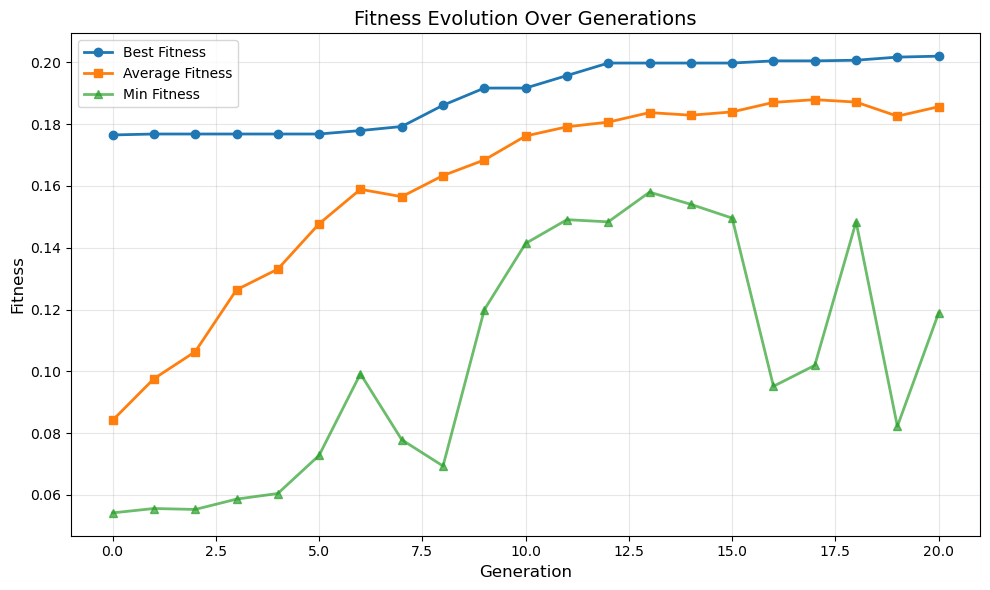

In [224]:
# Extract data from logbook
generations = logbook_deap.select("gen")
max_fitness = logbook_deap.select("max")
avg_fitness = logbook_deap.select("avg")
min_fitness = logbook_deap.select("min")

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(generations, max_fitness, label='Best Fitness', marker='o', linewidth=2)
plt.plot(generations, avg_fitness, label='Average Fitness', marker='s', linewidth=2)
plt.plot(generations, min_fitness, label='Min Fitness', marker='^', linewidth=2, alpha=0.7)

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Fitness Evolution Over Generations', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This was for an evolution with a population of 20 and 20 generations. We only used an ordered crossover and a mutated shuffle. Because we inserted the best individual of a previous run in the population, the starting fitness is relatively good. We can see the average fitness clearly increasing of the first 10 generations. After that point the fitness stagnates. That's why we started a run with a higher population, more variation in crossovers and mutation, to avoid this stagnation.

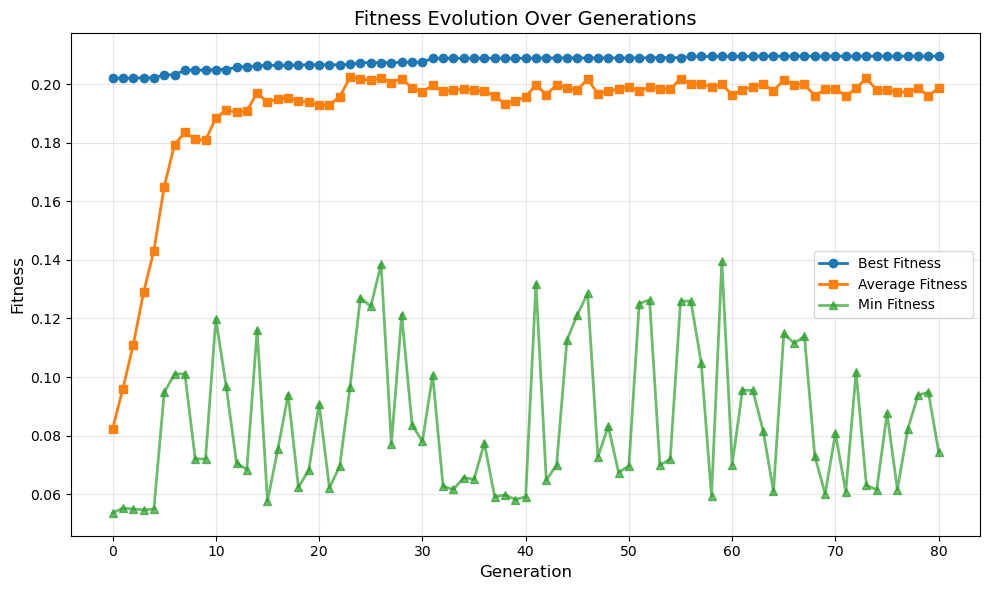

In [239]:
# Extract data from logbook
generations = logbook_deap.select("gen")
max_fitness = logbook_deap.select("max")
avg_fitness = logbook_deap.select("avg")
min_fitness = logbook_deap.select("min")

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(generations, max_fitness, label='Best Fitness', marker='o', linewidth=2)
plt.plot(generations, avg_fitness, label='Average Fitness', marker='s', linewidth=2)
plt.plot(generations, min_fitness, label='Min Fitness', marker='^', linewidth=2, alpha=0.7)

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Fitness Evolution Over Generations', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We see that the fitness still stagnates. We're trying to add an adaptive mutation rate: if the fitness stagnates, increase the mutation rate. We will also increase the mutation strength and increase the reset probability.

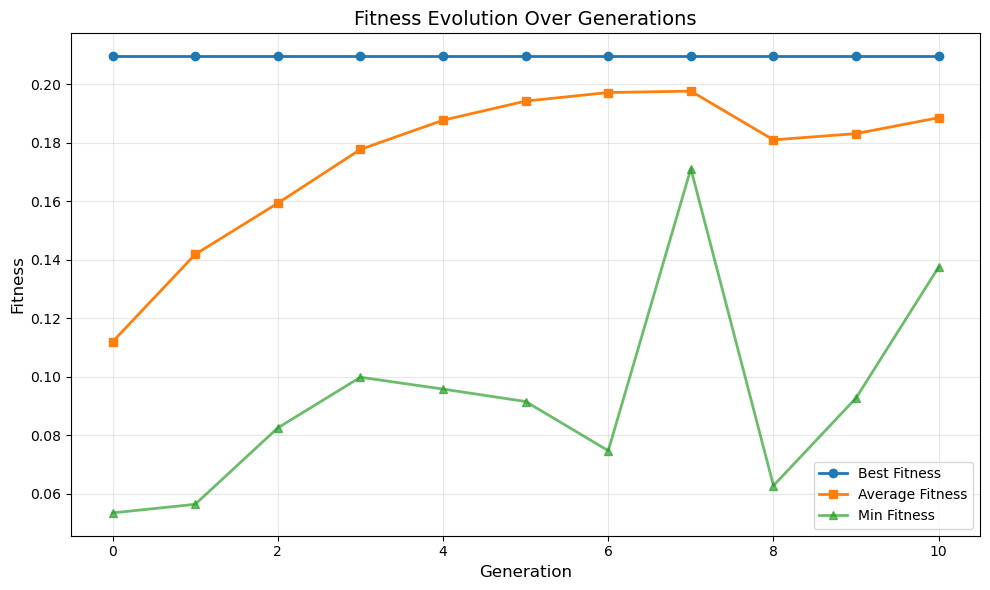

In [288]:
# Extract data from logbook
generations = logbook_deap.select("gen")
max_fitness = logbook_deap.select("max")
avg_fitness = logbook_deap.select("avg")
min_fitness = logbook_deap.select("min")

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(generations, max_fitness, label='Best Fitness', marker='o', linewidth=2)
plt.plot(generations, avg_fitness, label='Average Fitness', marker='s', linewidth=2)
plt.plot(generations, min_fitness, label='Min Fitness', marker='^', linewidth=2, alpha=0.7)

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Fitness Evolution Over Generations', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The fitness is still stagnating. Maybe this is the best the evaluation function can do? I'm trying a new evaluation function, that's not so harsh when a move is not the first selected move, but also awards fitness when the move is in the top 5.

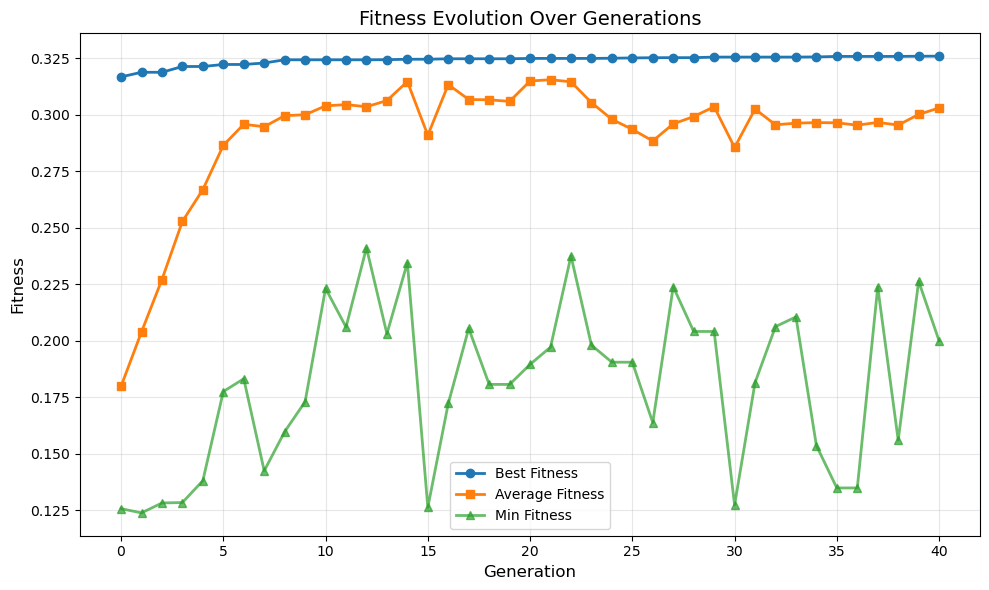

In [320]:
# Extract data from logbook
generations = logbook_deap.select("gen")
max_fitness = logbook_deap.select("max")
avg_fitness = logbook_deap.select("avg")
min_fitness = logbook_deap.select("min")

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(generations, max_fitness, label='Best Fitness', marker='o', linewidth=2)
plt.plot(generations, avg_fitness, label='Average Fitness', marker='s', linewidth=2)
plt.plot(generations, min_fitness, label='Min Fitness', marker='^', linewidth=2, alpha=0.7)

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Fitness Evolution Over Generations', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The new fitness function didn't give any improvement when we evaluated the result with the old function. We also still stagnated before 10 generations, even though we injected completely fresh individuals every 15 generations.

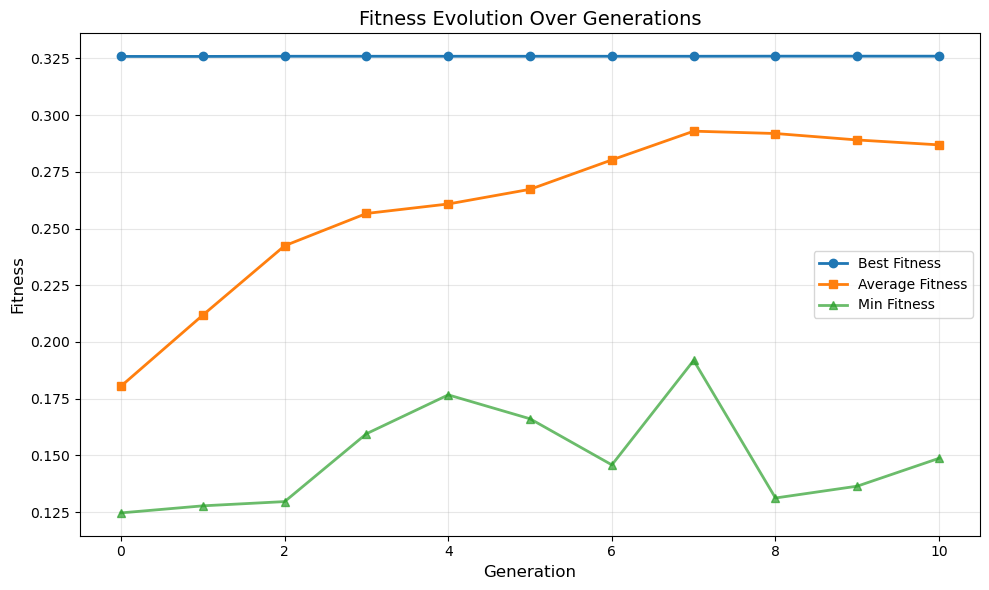

In [328]:
# Extract data from logbook
generations = logbook_deap.select("gen")
max_fitness = logbook_deap.select("max")
avg_fitness = logbook_deap.select("avg")
min_fitness = logbook_deap.select("min")

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(generations, max_fitness, label='Best Fitness', marker='o', linewidth=2)
plt.plot(generations, avg_fitness, label='Average Fitness', marker='s', linewidth=2)
plt.plot(generations, min_fitness, label='Min Fitness', marker='^', linewidth=2, alpha=0.7)

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Fitness Evolution Over Generations', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()